# Comparing models for retinal doppler vessel segmentation

In [1]:
import datasets
from PIL import Image
import os
import tqdm

import data_utils
import model_utils
import metrics

/home/saxel/DopplerHolographySegmentationTraining/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Dataset and dataloaders

In [2]:
def preprocess_sample(sample, size=(512, 512)):
    from PIL import Image

    sample["M0"] = sample["M0"].convert("L").resize(size, Image.BILINEAR)
    sample["correlation"] = sample["correlation"].convert("L").resize(size, Image.BILINEAR)
    sample["diasys"] = sample["diasys"].convert("L").resize(size, Image.BILINEAR)
    sample["maskArtery"] = sample["maskArtery"].convert("L").resize(size, Image.NEAREST)
    sample["maskVein"] = sample["maskVein"].convert("L").resize(size, Image.NEAREST)
    return sample

In [3]:
CACHE_DIR = "data/cache_holo_doppler_segmentation"

if os.path.exists(CACHE_DIR):
    ds_processed = datasets.load_from_disk(CACHE_DIR)
else:
    ds = datasets.load_dataset(
        "DigitalHolography/HoloDopplerSegISBI",
        revision="main",
        data_files={
            "train": "train.jsonl",
            "test": "test.jsonl"
        },
    )
    for col in ["M0", "correlation", "diasys", "maskArtery", "maskVein"]:
        ds = ds.cast_column(col, datasets.Image())
    
    size = (512, 512)
    ds_processed = ds.map(preprocess_sample,fn_kwargs={"size": (512, 512)},num_proc=8)
    ds_processed.save_to_disk(CACHE_DIR)

Saving the dataset (1/1 shards): 100%|██████████| 24/24 [00:00<00:00, 443.87 examples/s]


In [4]:
ds_processed

DatasetDict({
    train: Dataset({
        features: ['id', 'M0', 'correlation', 'diasys', 'maskArtery', 'maskVein'],
        num_rows: 121
    })
    test: Dataset({
        features: ['id', 'M0', 'correlation', 'diasys', 'maskArtery', 'maskVein'],
        num_rows: 24
    })
})

In [5]:
from fastai.vision.all import *

class ToMultiLabelY(Transform):
    order = 10  # ensure it runs AFTER spatial transforms

    def __init__(self, num_classes=2):
        self.num_classes = num_classes

    def encodes(self, y: TensorMask):
        y = torch.tensor(np.array(y)).long()

        channels = [(y & (1 << c)) > 0 for c in range(self.num_classes)]
        return torch.stack(channels).float()

In [6]:
from data_utils import BinaryVesselDataset, ArteryVeinDataset

def make_dls(DatasetClass, hf_ds, input=["M0"], bs=8, img_size=512, num_classes=2):

    train_ds = DatasetClass(hf_ds["train"], input=input)
    valid_ds = DatasetClass(hf_ds["test"], input=input)

    item_tfms = [
        RandomResizedCrop(img_size, min_scale=0.08),
        ToTensor(),
        ToMultiLabelY(num_classes=num_classes),
    ]

    item_tfms_valid = [
        Resize(img_size),
        ToTensor(),
        ToMultiLabelY(num_classes=num_classes),
    ]

    batch_tfms = [IntToFloatTensor()]

    train_dl = TfmdDL(
        train_ds, bs=bs,
        after_item=item_tfms,
        after_batch=batch_tfms,
        shuffle=True,
        num_workers=0,
    )

    valid_dl = TfmdDL(
        valid_ds, bs=1,
        after_item=item_tfms_valid,
        after_batch=batch_tfms,
        num_workers=0,
    )

    return DataLoaders(train_dl, valid_dl)

# Usage
dls_binary = make_dls(BinaryVesselDataset, ds_processed, input=["M0"], bs=1, num_classes=1)
# dls_binary_one_hot = make_dls(BinaryVesselDataset, ds_processed, input=["M0"], bs=2, one_hot=True, num_classes=1)
# dls_av = make_dls(ArteryVeinDataset, ds_processed, input=["M0","M0","M0"], bs=2)
# dls_av_corr = make_dls(ArteryVeinDataset, ds_processed, input=["M0", "M0", "correlation"], bs=2)
# dls_av_sys = make_dls(ArteryVeinDataset, ds_processed, input=["M0", "M0", "diasys"], bs=2)
dls_av_sys_corr = make_dls(ArteryVeinDataset, ds_processed, input=["M0", "correlation", "diasys"], bs=2)
# dls_av_sys_corr_one_hot = make_dls(ArteryVeinDataset, ds_processed, input=["M0", "correlation", "diasys"], bs=2, one_hot=True, num_classes=2)

In [7]:
img, mask = dls_binary.train.one_batch()
img.shape, mask.shape

/tmp/ipykernel_4110695/3339217953.py:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y = torch.tensor(np.array(y)).long()


(torch.Size([1, 1, 512, 512]), torch.Size([1, 1, 512, 512]))

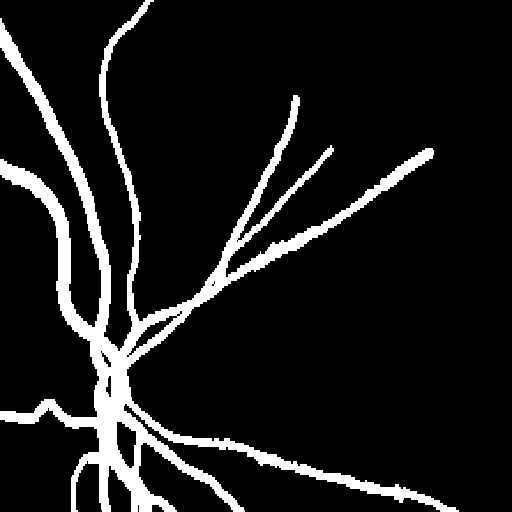

In [8]:
Image.fromarray((mask[0][0].numpy().astype(np.uint8)*255))

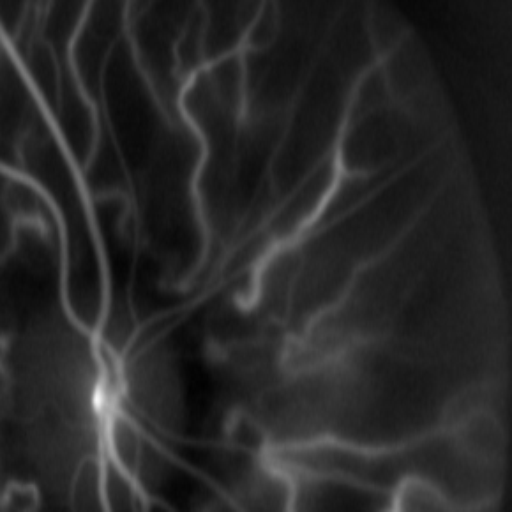

In [9]:
M0 = torch.stack([img[0][0], img[0][0], img[0][0]], dim=0)
Image.fromarray((M0.permute(1,2,0).numpy()*255).astype(np.uint8))

In [10]:
print(f"Training samples: {len(dls_av_sys_corr.train_ds)}")
print(f"Validation samples: {len(dls_av_sys_corr.valid_ds)}")

Training samples: 121
Validation samples: 24


In [11]:
img, mask = dls_av_sys_corr.train.one_batch()
img.shape, mask.shape

/tmp/ipykernel_4110695/3339217953.py:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y = torch.tensor(np.array(y)).long()


(torch.Size([2, 3, 512, 512]), torch.Size([2, 2, 512, 512]))

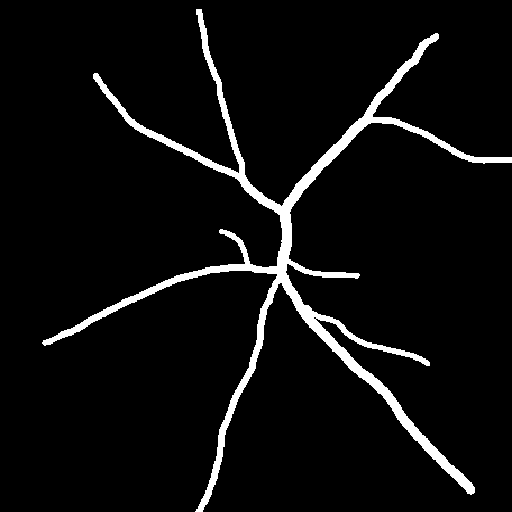

In [12]:
Image.fromarray((mask[0][0].numpy().astype(np.uint8)*255))

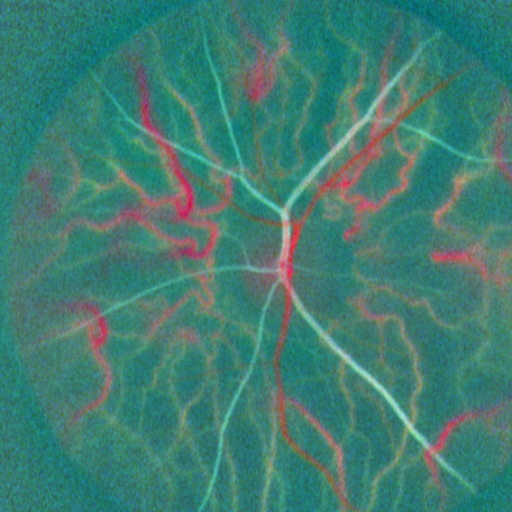

In [13]:
Image.fromarray((img[0].permute(1,2,0).numpy()*255).astype(np.uint8))

## Evaluation metrics

### Sensitivity (Recall, True Positive Rate)
$
\text{Sensitivity} = \frac{TP}{TP + FN}
$
* **TP**: correctly predicted vessel pixels
* **FN**: missed vessel pixels

Sensitivity measures how much of the ground truth was successfully captured. It penalizes false negatives (missed vessels), but not false positives.

In [14]:
from metrics import sensitivity

### Dice coefficient (F1 score for segmentation)

$
\text{Dice} = \frac{2TP}{2TP + FP + FN}
$

Similar to IoU, it measures the overlap between prediction and ground truth. 
It is suited for unbalanced classes (our case).

In [15]:
from metrics import dice

### clDice (centerline Dice)

$
\text{clDice} = \frac{2 \cdot T_{prec} \cdot T_{sens}}{T_{prec} + T_{sens}}
$

It measures the topological correctness of tubular structures, complementing dice which ignores topology.

It compares:
- skeleton of prediction vs GT
- and vice versa

In [16]:
from metrics import clDice

### HD95 (Hausdorff Distance 95%)

It measures the worst-case boundary error. We take the **95th percentile** instead of max to avoid extreme outliers dominating the metric.

In [17]:
from metrics import hausdorff_distance

## Losses

### Cross Entropy
---
Cross-Entropy Loss is a commonly used loss function for classification tasks. It measures the difference between the predicted probability distribution and the true distribution (one-hot encoded labels).

$CE = -\sum_{i=1}^{C} y_ilog(\hat{y_i})$

In our case, the classes have a heavy desequilibrium. There is more background than vessels. Therefore, we can attribute a weight to each class, so that missclassifying vessels generates more error than missclassifying background.

$CE = -\sum_{i=1}^{C} w_i * y_i log(\hat{y_i})$

In [18]:
def get_weights(dls):
    coeffs = np.zeros(2)
    for x, y in dls.train_ds:
        values, counts = np.unique(np.array(y), return_counts=True)
        if len(values) != 2:
            values, counts = np.unique(np.where(np.array(y)>127, 1, 0), return_counts=True)
        coeffs += counts / counts.sum()
    return 1- torch.Tensor(coeffs / len(dls.train_ds))

In [19]:
def weighted_bce_loss(logits, targets, pos_weight):
    weights = (1 - targets) + targets * pos_weight[None, :, None, None]
    bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
    return (weights * bce).mean()

### Focal loss
---
Focal Loss was introduced by *Lin et al* of Facebook AI Research in 2017 as a means of combatting extremely imbalanced datasets where positive cases were relatively rare. Their paper "Focal Loss for Dense Object Detection" is retrievable here: https://arxiv.org/abs/1708.02002

It is similar to the weighted CE

$CE = -\sum_{i=1}^{C} (1-\hat{y_i})^{\gamma} * y_ilog(\hat{y_i})$

### Dice Loss
---
The Dice coefficient, or Dice-S﷿﷿rensen coefficient, is a common metric for pixel segmentation that can also be modified to act as a loss function:

$DSC = \frac{2|X \cap Y|}{|X| + |Y|}$

Since it does not penalize per-pixel classification errors, it needs an additional loss, like the CE or Focal loss.

In [20]:
import torch
import torch.nn.functional as F
import torch.nn as nn

class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1e-6, pos_weight=None, dice_weight=0.5, bce_weight=0.5):
        super().__init__()
        self.smooth = smooth
        self.dice_weight = dice_weight
        self.bce_weight = bce_weight
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        """
        logits: [B, C, H, W] - raw outputs from model
        targets: [B, C, H, W] - binary masks (0 or 1)
        """
        # BCE Loss
        if len(targets.shape) == 3:
            targets = targets.unsqueeze(1)
        logits = logits.float()
        targets = targets.float()
        bce_loss_fn = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight, reduction='mean')
        bce = bce_loss_fn(logits, targets)

        # Dice Loss
        probs = torch.sigmoid(logits)
        num = (probs * targets).sum(dim=(2, 3))  # per batch & class
        den = (probs + targets).sum(dim=(2, 3))

        dice_score = (2 * num + self.smooth) / (den + self.smooth)
        dice_loss = 1 - dice_score.mean()

        return self.bce_weight * bce + self.dice_weight * dice_loss

In [21]:
class CEDiceLossFastai:
    "Dice and CE combined"
    def __init__(self, axis=1, smooth=1., alpha=1.):
        store_attr()
        self.ce = CrossEntropyLossFlat(axis=axis)
        self.dice_loss = DiceLoss(axis, smooth)
        
    def __call__(self, pred, targ):
        return self.ce(pred, targ) + self.alpha * self.dice_loss(pred, targ)
    
    def decodes(self, x):    return x.argmax(dim=self.axis)
    def activation(self, x): return F.softmax(x, dim=self.axis)

In [22]:
class FocalDiceLossFastai:
    "Dice and Focal combined"
    def __init__(self, axis=1, smooth=1., alpha=1.):
        store_attr()
        self.focal_loss = FocalLossFlat(axis=axis)
        self.dice_loss =  DiceLoss(axis, smooth)
        
    def __call__(self, pred, targ):
        return self.focal_loss(pred, targ) + self.alpha * self.dice_loss(pred, targ)
    
    def decodes(self, x):    return x.argmax(dim=self.axis)
    def activation(self, x): return F.softmax(x, dim=self.axis)

### CL-Dice Loss

CL-Dice combines:

- **Dice loss** (region overlap)
- **Centerline Dice loss** (clDice), which compares the skeletons of prediction and ground truth masks

It is defined as:

$$clDice
= \frac{2﷿﷿﷿﷿﷿﷿﷿﷿_﷿﷿﷿﷿ ﷿﷿﷿ ﷿﷿﷿﷿﷿﷿﷿﷿_﷿﷿﷿﷿}{﷿﷿﷿﷿﷿﷿﷿﷿_﷿﷿﷿﷿ + ﷿﷿﷿﷿﷿﷿﷿﷿_﷿﷿﷿﷿ + ﷿﷿﷿﷿}$$

Where:

$﷿﷿﷿﷿﷿﷿﷿﷿_﷿﷿﷿﷿$ = skeleton of prediction ﷿﷿﷿ mask

$﷿﷿﷿﷿﷿﷿﷿﷿_﷿﷿﷿﷿$ = skeleton of mask ﷿﷿﷿ prediction

In [23]:
def soft_skeletonize(img, thresh_width=10):
    for _ in range(thresh_width):
        min_pool = -F.max_pool2d(-img, kernel_size=3, stride=1, padding=1)
        img = torch.relu(img - torch.relu(img - min_pool))
    return img

class CLDiceLoss(nn.Module):
    def __init__(self, smooth=1e-6, cl_weight=0.5, dice_weight=0.3, bce_weight=0.2, pos_weight=None):
        super().__init__()
        self.smooth = smooth
        self.cl_weight = cl_weight
        self.dice_weight = dice_weight
        self.bce_weight = bce_weight
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        if len(targets.shape) == 3:
            targets = targets.unsqueeze(1)
        logits = logits.float()
        targets = targets.float()

        probs = torch.sigmoid(logits)
        bce = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight)(logits, targets)

        # Standard Dice Loss
        intersection = (probs * targets).sum(dim=(2, 3))
        union = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
        dice_loss = 1 - ((2 * intersection + self.smooth) / (union + self.smooth)).mean()

        # clDice
        pred_skeleton = soft_skeletonize(probs)
        gt_skeleton = soft_skeletonize(targets)

        tprec = ((pred_skeleton * targets).sum(dim=(2, 3)) + self.smooth) / (pred_skeleton.sum(dim=(2, 3)) + self.smooth)
        tsens = ((gt_skeleton * probs).sum(dim=(2, 3)) + self.smooth) / (gt_skeleton.sum(dim=(2, 3)) + self.smooth)

        cl_dice_loss = 1 - (2 * tprec * tsens / (tprec + tsens + self.smooth)).mean()

        return self.cl_weight * cl_dice_loss + self.dice_weight * dice_loss + self.bce_weight * bce

### Topoloss

In [24]:
import gudhi as gd
from pylab import *
import torch

def compute_dgm_force(lh_dgm, gt_dgm, pers_thresh=0.03, pers_thresh_perfect=0.99, do_return_perfect=False):
    """
    Compute the persistent diagram of the image

    Args:
        lh_dgm: likelihood persistent diagram.
        gt_dgm: ground truth persistent diagram.
        pers_thresh: Persistent threshold, which also called dynamic value, which measure the difference.
        between the local maximum critical point value with its neighouboring minimum critical point value.
        The value smaller than the persistent threshold should be filtered. Default: 0.03
        pers_thresh_perfect: The distance difference between two critical points that can be considered as
        correct match. Default: 0.99
        do_return_perfect: Return the persistent point or not from the matching. Default: False

    Returns:
        force_list: The matching between the likelihood and ground truth persistent diagram
        idx_holes_to_fix: The index of persistent points that requires to fix in the following training process
        idx_holes_to_remove: The index of persistent points that require to remove for the following training
        process

    """

    lh_pers = abs(lh_dgm[:, 1] - lh_dgm[:, 0])
    if (gt_dgm.shape[0] == 0):
        gt_pers = None
        gt_n_holes = 0
    else:
        gt_pers = gt_dgm[:, 1] - gt_dgm[:, 0]
        gt_n_holes = gt_pers.size  # number of holes in gt

    if (gt_pers is None or gt_n_holes == 0):
        idx_holes_to_fix = list()
        idx_holes_to_remove = list(set(range(lh_pers.size)))
        idx_holes_perfect = list()
    else:
        # check to ensure that all gt dots have persistence 1
        tmp = gt_pers > pers_thresh_perfect

        # get "perfect holes" - holes which do not need to be fixed, i.e., find top
        # lh_n_holes_perfect indices
        # check to ensure that at least one dot has persistence 1 it is the hole
        # formed by the padded boundary
        # if no hole is ~1 (ie >.999) then just take all holes with max values
        tmp = lh_pers > pers_thresh_perfect  # old: assert tmp.sum() >= 1
        lh_pers_sorted_indices = np.argsort(lh_pers)[::-1]
        if np.sum(tmp) >= 1:
            lh_n_holes_perfect = tmp.sum()
            idx_holes_perfect = lh_pers_sorted_indices[:lh_n_holes_perfect]
        else:
            idx_holes_perfect = list()

        # find top gt_n_holes indices
        idx_holes_to_fix_or_perfect = lh_pers_sorted_indices[:gt_n_holes]

        # the difference is holes to be fixed to perfect
        idx_holes_to_fix = list(
            set(idx_holes_to_fix_or_perfect) - set(idx_holes_perfect))

        # remaining holes are all to be removed
        idx_holes_to_remove = lh_pers_sorted_indices[gt_n_holes:]

    # only select the ones whose persistence is large enough
    # set a threshold to remove meaningless persistence dots
    pers_thd = pers_thresh
    idx_valid = np.where(lh_pers > pers_thd)[0]
    idx_holes_to_remove = list(
        set(idx_holes_to_remove).intersection(set(idx_valid)))

    force_list = np.zeros(lh_dgm.shape)
    
    # push each hole-to-fix to (0,1)
    force_list[idx_holes_to_fix, 0] = 0 - lh_dgm[idx_holes_to_fix, 0]
    force_list[idx_holes_to_fix, 1] = 1 - lh_dgm[idx_holes_to_fix, 1]

    # push each hole-to-remove to (0,1)
    force_list[idx_holes_to_remove, 0] = lh_pers[idx_holes_to_remove] / \
                                         math.sqrt(2.0)
    force_list[idx_holes_to_remove, 1] = -lh_pers[idx_holes_to_remove] / \
                                         math.sqrt(2.0)

    if (do_return_perfect):
        return force_list, idx_holes_to_fix, idx_holes_to_remove, idx_holes_perfect

    return force_list, idx_holes_to_fix, idx_holes_to_remove

def getCriticalPoints(likelihood):
    """
    Compute the critical points of the image (Value range from 0 -> 1)

    Args:
        likelihood: Likelihood image from the output of the neural networks

    Returns:
        pd_lh:  persistence diagram.
        bcp_lh: Birth critical points.
        dcp_lh: Death critical points.
        Bool:   Skip the process if number of matching pairs is zero.

    """
    lh = 1 - likelihood
    lh_vector = np.asarray(lh).flatten()

    lh_cubic = gd.CubicalComplex(
        dimensions=[lh.shape[0], lh.shape[1]],
        top_dimensional_cells=lh_vector
    )

    Diag_lh = lh_cubic.persistence(homology_coeff_field=2, min_persistence=0)
    pairs_lh = lh_cubic.cofaces_of_persistence_pairs()

    # If the paris is 0, return False to skip
    if (len(pairs_lh[0])==0): return 0, 0, 0, False

    # return persistence diagram, birth/death critical points
    pd_lh = np.array([[lh_vector[pairs_lh[0][0][i][0]], lh_vector[pairs_lh[0][0][i][1]]] for i in range(len(pairs_lh[0][0]))])
    bcp_lh = np.array([[pairs_lh[0][0][i][0]//lh.shape[1], pairs_lh[0][0][i][0]%lh.shape[1]] for i in range(len(pairs_lh[0][0]))])
    dcp_lh = np.array([[pairs_lh[0][0][i][1]//lh.shape[1], pairs_lh[0][0][i][1]%lh.shape[1]] for i in range(len(pairs_lh[0][0]))])

    return pd_lh, bcp_lh, dcp_lh, True

def getTopoLoss(likelihood_tensor, gt_tensor, topo_size=100):
    """
    Calculate the topology loss of the predicted image and ground truth image 
    Warning: To make sure the topology loss is able to back-propagation, likelihood 
    tensor requires to clone before detach from GPUs. In the end, you can hook the
    likelihood tensor to GPUs device.

    Args:
        likelihood_tensor:   The likelihood pytorch tensor.
        gt_tensor        :   The groundtruth of pytorch tensor.
        topo_size        :   The size of the patch is used. Default: 100

    Returns:
        loss_topo        :   The topology loss value (tensor)

    """

    likelihood = torch.sigmoid(likelihood_tensor).clone()
    gt = gt_tensor.clone()

    likelihood = torch.squeeze(likelihood).cpu().detach().numpy()
    gt = torch.squeeze(gt).cpu().detach().numpy()

    topo_cp_weight_map = np.zeros(likelihood.shape)
    topo_cp_ref_map = np.zeros(likelihood.shape)

    for y in range(0, likelihood.shape[0], topo_size):
        for x in range(0, likelihood.shape[1], topo_size):
            lh_patch = likelihood[y:min(y + topo_size, likelihood.shape[0]),
                         x:min(x + topo_size, likelihood.shape[1])]
            gt_patch = gt[y:min(y + topo_size, gt.shape[0]),
                         x:min(x + topo_size, gt.shape[1])]

            if(np.min(lh_patch) == 1 or np.max(lh_patch) == 0): continue
            if(np.min(gt_patch) == 1 or np.max(gt_patch) == 0): continue

            # Get the critical points of predictions and ground truth
            pd_lh, bcp_lh, dcp_lh, pairs_lh_pa = getCriticalPoints(lh_patch)
            pd_gt, bcp_gt, dcp_gt, pairs_lh_gt = getCriticalPoints(gt_patch)

            # print("pd_lh.shape", pd_lh.shape, "bcp_lh.shape", bcp_lh.shape, "dcp_lh.shape", dcp_lh.shape, "pairs_lh_pa", pairs_lh_pa)

            # If the pairs not exist, continue for the next loop
            if not(pairs_lh_pa): continue
            if not(pairs_lh_gt): continue
            if (pd_lh.shape[0] == 0 or pd_gt.shape[0] == 0): continue

            force_list, idx_holes_to_fix, idx_holes_to_remove = compute_dgm_force(pd_lh, pd_gt, pers_thresh=0.03)

            if (len(idx_holes_to_fix) > 0 or len(idx_holes_to_remove) > 0):
                for hole_indx in idx_holes_to_fix:
                    if (int(bcp_lh[hole_indx][0]) >= 0 and int(bcp_lh[hole_indx][0]) < likelihood.shape[0] and int(
                            bcp_lh[hole_indx][1]) >= 0 and int(bcp_lh[hole_indx][1]) < likelihood.shape[1]):
                        topo_cp_weight_map[y + int(bcp_lh[hole_indx][0]), x + int(
                            bcp_lh[hole_indx][1])] = 1  # push birth to 0 i.e. min birth prob or likelihood
                        topo_cp_ref_map[y + int(bcp_lh[hole_indx][0]), x + int(bcp_lh[hole_indx][1])] = 0
                    if (int(dcp_lh[hole_indx][0]) >= 0 and int(dcp_lh[hole_indx][0]) < likelihood.shape[
                        0] and int(dcp_lh[hole_indx][1]) >= 0 and int(dcp_lh[hole_indx][1]) <
                            likelihood.shape[1]):
                        topo_cp_weight_map[y + int(dcp_lh[hole_indx][0]), x + int(
                            dcp_lh[hole_indx][1])] = 1  # push death to 1 i.e. max death prob or likelihood
                        topo_cp_ref_map[y + int(dcp_lh[hole_indx][0]), x + int(dcp_lh[hole_indx][1])] = 1
                for hole_indx in idx_holes_to_remove:
                    if (int(bcp_lh[hole_indx][0]) >= 0 and int(bcp_lh[hole_indx][0]) < likelihood.shape[
                        0] and int(bcp_lh[hole_indx][1]) >= 0 and int(bcp_lh[hole_indx][1]) <
                            likelihood.shape[1]):
                        topo_cp_weight_map[y + int(bcp_lh[hole_indx][0]), x + int(
                            bcp_lh[hole_indx][1])] = 1  # push birth to death  # push to diagonal
                        if (int(dcp_lh[hole_indx][0]) >= 0 and int(dcp_lh[hole_indx][0]) < likelihood.shape[
                            0] and int(dcp_lh[hole_indx][1]) >= 0 and int(dcp_lh[hole_indx][1]) <
                                likelihood.shape[1]):
                            topo_cp_ref_map[y + int(bcp_lh[hole_indx][0]), x + int(bcp_lh[hole_indx][1])] = \
                                lh_patch[int(dcp_lh[hole_indx][0]), int(dcp_lh[hole_indx][1])]
                        else:
                            topo_cp_ref_map[y + int(bcp_lh[hole_indx][0]), x + int(bcp_lh[hole_indx][1])] = 1
                    if (int(dcp_lh[hole_indx][0]) >= 0 and int(dcp_lh[hole_indx][0]) < likelihood.shape[
                        0] and int(dcp_lh[hole_indx][1]) >= 0 and int(dcp_lh[hole_indx][1]) <
                            likelihood.shape[1]):
                        topo_cp_weight_map[y + int(dcp_lh[hole_indx][0]), x + int(
                            dcp_lh[hole_indx][1])] = 1  # push death to birth # push to diagonal
                        if (int(bcp_lh[hole_indx][0]) >= 0 and int(bcp_lh[hole_indx][0]) < likelihood.shape[
                            0] and int(bcp_lh[hole_indx][1]) >= 0 and int(bcp_lh[hole_indx][1]) <
                                likelihood.shape[1]):
                            topo_cp_ref_map[y + int(dcp_lh[hole_indx][0]), x + int(dcp_lh[hole_indx][1])] = \
                                lh_patch[int(bcp_lh[hole_indx][0]), int(bcp_lh[hole_indx][1])]
                        else:
                            topo_cp_ref_map[y + int(dcp_lh[hole_indx][0]), x + int(dcp_lh[hole_indx][1])] = 0

    topo_cp_weight_map = torch.tensor(topo_cp_weight_map, dtype=torch.float).cuda()
    topo_cp_ref_map = torch.tensor(topo_cp_ref_map, dtype=torch.float).cuda()

    # Measuring the MSE loss between predicted critical points and reference critical points
    loss_topo = (((likelihood_tensor * topo_cp_weight_map) - topo_cp_ref_map) ** 2).sum()
    return loss_topo

In [25]:
class CETopoloss(nn.Module):
    def __init__(self, smooth=1e-6, coeff = 0.1, pos_weight=None):
        super().__init__()
        self.smooth = smooth
        self.lambda_ = coeff
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        """
        logits: [B, C, H, W] - raw outputs from model
        targets: [B, C, H, W] - binary masks (0 or 1)
        """
        if len(targets.shape) == 3:
            targets = targets.unsqueeze(1)
        logits = logits.float()
        targets = targets.float()

        # BCE Loss
        bce_loss_fn = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight, reduction='mean')
        bce = bce_loss_fn(logits, targets)

        # Dice Loss
        topo_loss=0
        # print("logits.shape, targets.shape", logits.shape, targets.shape)
        for i in range(logits.shape[0]):
            topo_loss += getTopoLoss(logits[i], targets[i])
        topo_loss /= logits.shape[0]

        return bce + self.lambda_ * topo_loss

### RRLoss

In [26]:
import torch.nn as nn
import torch
import torchvision.utils as vutils

class BCE3Loss(nn.Module):
    """ BCE3 loss for the simultaneous segmentation of arteries [A], veins [V]
    and vessel tree [VT] (AV3).
    indices:
        artery: 0
        vein: 1
        vessel_tree (artery+vein): 2
    """

    def __init__(self):
        super().__init__()
        self.loss = nn.BCEWithLogitsLoss()

    def forward(self, pred_vessels, vessels, only_av=False):
        if pred_vessels.ndim == 3:
            pred_vessels = pred_vessels.unsqueeze(1)

        if vessels.ndim == 3:
            vessels = vessels.unsqueeze(1)

        C = pred_vessels.shape[1]

        if C == 1:
            return self.loss(pred_vessels, vessels)

        elif C == 2:
            pred_a, pred_v = pred_vessels[:, 0], pred_vessels[:, 1]
            gt_a, gt_v = vessels[:, 0], vessels[:, 1]
            
            return self.loss(pred_a, gt_a) + self.loss(pred_v, gt_v)

        elif C >= 3:
            pred_a, pred_v, pred_vt = pred_vessels[:, 0], pred_vessels[:, 1], pred_vessels[:, 2]
            gt_a, gt_v, gt_vt = vessels[:, 0], vessels[:, 1], vessels[:, 2]

            loss = self.loss(pred_a, gt_a) + self.loss(pred_v, gt_v)

            if not only_av:
                loss += self.loss(pred_vt, gt_vt)

            return loss

    def save_predicted(self, prediction, fname):
        prediction_processed = self.process_predicted(prediction)
        vutils.save_image(prediction_processed, fname)

    def process_predicted(self, prediction):
        return torch.sigmoid(prediction.clone())

class RRLoss(nn.Module):
    """Recursive refinement loss.
    """
    def __init__(self, base_criterion, refine_only_av=True):
        super().__init__()
        self.base_criterion = base_criterion
        self.refine_only_av=refine_only_av

    def forward(self, predictions, gt):
        v_channel = gt[:, 0:1, :, :] | gt[:, 1:2, :, :]  # shape (2, 1, 512, 512)
        gt = torch.cat([gt, v_channel], dim=1) 
        
        gt = gt.float()

        loss_1 = self.base_criterion(predictions[0], gt)
        if len(predictions) == 1:
            return loss_1

        # mask = torch.sigmoid(predictions[0][:,2,:,:])

        # Second loss (refinement) inspired by Mosinska:CVPR:2018.
        loss_2 = 1 * self.base_criterion(predictions[1], gt, only_av=self.refine_only_av)
        if len(predictions) == 2:
            return loss_1 + loss_2
        for i, prediction in enumerate(predictions[2:], 2):
            loss_2 += i * self.base_criterion(prediction, gt, only_av=self.refine_only_av)

        K = len(predictions[1:])
        Z = (1/2) * K * (K + 1)

        loss_2 *= 1/Z

        loss = loss_1 + loss_2

        return loss

    def save_predicted(self, predictions, fname):
        self.base_criterion.save_predicted(predictions[-1], fname)

    def process_predicted(self, predictions):
        new_predictions = []
        for prediction in predictions:
            new_predictions.append(self.base_criterion.process_predicted(prediction))
        return new_predictions

class IterativeLoss(nn.Module):
    def __init__(self, base_loss):
        super().__init__()
        self.base_loss = base_loss

    def forward(self, preds, target):
        target = (target > 0).float()
        if not isinstance(preds, list):
            return self.base_loss(preds, target)

        total = 0
        K = len(preds)

        for i, p in enumerate(preds):
            weight = (i+1)
            total += weight * self.base_loss(p, target)

        return total / (K*(K+1)/2)

## Model training

In [27]:
import losses
import metrics
import model_utils
import gc

In [28]:
def detect_model_version(model_folder, model_name, extension=".pth"):
    import os
    import re

    version = -1
    previous_version = ""
    pattern = re.compile(rf"{re.escape(model_name)}_(\d+){re.escape(extension)}$")
    for filename in os.listdir(model_folder):
        match = pattern.match(filename)
        if match:
            ver = int(match.group(1))
            if ver > version:
                version = ver
                previous_version = filename
    return version, previous_version

In [29]:
root = Path("saved_models")

In [30]:
#def train_model(model, dls, loss_func, model_name, model_dir, metrics, num_epochs=300, lr=1e-3, export_onnx=False, load_pretrained=False, extension=".pth"):
#    version, filename = detect_model_version(model_dir, model_name, extension=extension)
#
#    if load_pretrained and filename is not None:
#        model.load_state_dict(torch.load(model_dir / filename))
#
#    model_name = f"{model_name}_{version+1}"
#    print(f"Training {model_name}...")
#
#    learn = Learner(dls, model, loss_func=loss_func, metrics=metrics, model_dir=model_dir)
#    learn.fit_one_cycle(num_epochs, lr, cbs=[SaveModelCallback(monitor='valid_loss', fname=model_name), EarlyStoppingCallback(monitor='valid_loss', min_delta=0.1e-5, patience=30)])
#
#    if export_onnx:
#        save_path = model_dir / f"{model_name}.onnx"
#        model_utils.export_onnx(learn.model.cpu(), save_path)
#        print(f"Model saved to {save_path}")
#
#    torch.cuda.empty_cache()
#    gc.collect()
#
#   return model

In [31]:
import torch
import numpy as np
from torch.utils.data import DataLoader, DistributedSampler
from data_utils import BinaryVesselDataset  # signature native, sans transform

# ── Paramètres ───────────────────────────────────────────────────────────────
DILOCO_BATCH_SIZE = 2
IMG_SIZE          = 512
WORLD_SIZE        = torch.cuda.device_count()
RANK              = 0  # le rank 0 est utilisé ici pour le process principal

# ── Dataset brut depuis dsprocessed (déjà chargé) ────────────────────────────
# BinaryVesselDataset n'accepte pas de 'transform', on utilise sa signature native
ds_raw = BinaryVesselDataset(ds_processed["train"], input=["M0"])
# ── DistributedSampler + DataLoader PyTorch pur ───────────────────────────────
train_sampler = DistributedSampler(
    ds_raw,
    num_replicas=WORLD_SIZE,
    rank=RANK,
    shuffle=True
)

diloco_loader = DataLoader(
    ds_raw,
    batch_size=DILOCO_BATCH_SIZE,
    sampler=train_sampler,
    num_workers=0,   # 0 pour éviter les conflits de fork dans le notebook
    pin_memory=True,
)

print(f"Dataset size   : {len(ds_raw)}")
print(f"World size     : {WORLD_SIZE}")
print(f"Batches/rank   : {len(diloco_loader)}")

Dataset size   : 121
World size     : 1
Batches/rank   : 61


In [32]:
import gc
import sys
import torch
import torch.multiprocessing as mp

sys.path.insert(0, 'MiniDiLoCo')
from MiniDiLoCo.train import Trainer, diloco_worker   # ← importé depuis le fichier .py

def train_model(model, dls, loss_func, model_name, model_dir, metrics,
                num_epochs=300, lr=1e-3, export_onnx=False,
                load_pretrained=False, extension=".pth"):

    version, filename = detect_model_version(model_dir, model_name, extension=extension)

    if load_pretrained and filename is not None:
        model.load_state_dict(torch.load(model_dir / filename))

    model_name = f"{model_name}_{version+1}"
    print(f"Training {model_name}...")

    save_path = str(model_dir / f"{model_name}{extension}")
    model.share_memory()  # nécessaire avant mp.spawn

    mp.spawn(
        diloco_worker,
        args=(WORLD_SIZE, model, ds_raw, DILOCO_BATCH_SIZE, loss_func, num_epochs, lr, save_path),
        nprocs=WORLD_SIZE,
        join=True
    )

    # ── Recharger les poids entraînés dans le modèle du processus principal ──
    model.load_state_dict(torch.load(save_path))
    # ─────────────────────────────────────────────────────────────────────────


    if export_onnx:
        save_path = model_dir / f"{model_name}.onnx"
        model_utils.export_onnx(model.cpu(), save_path)
        print(f"Model saved to {save_path}")

    torch.cuda.empty_cache()
    gc.collect()

    return model

In [33]:
img_size=512
training_tools = {
    'binary':{
        'input_shape': (8, 1, img_size, img_size),
        'num_classes': 1,
        'dataloader': dls_binary,
        'save_folder': root / "binary",
    },
    'artery_vein':{
        'input_shape': (2, 3, img_size, img_size),
        'num_classes': 2,
        'dataloader': dls_av_sys_corr,
        'save_folder': root / "av_sys_corr",
    }
}

In [34]:
mode = 'binary'
#mode = 'artery_vein'

In [35]:
from models.custom_unet.unet import UNet

device = 'cuda'
losses : dict = {'ce': BCEWithLogitsLossFlat(),}
metric_list = [sensitivity, dice, clDice, hausdorff_distance]

input_shape = training_tools[mode]['input_shape']
num_channels = input_shape[1]
num_classes = training_tools[mode]['num_classes']

dataloader = training_tools[mode]['dataloader']
save_folder = training_tools[mode]['save_folder']
os.makedirs(save_folder, exist_ok=True)

unet_params: dict = {'upsample': ['bilinear']}

num_epochs = 10

export_onnx = False

for criterion_str, criterion in losses.items():

    # ####### UNet ########
    for upsample in unet_params['upsample']:
         unet = UNet(in_channels=num_channels, n_classes=num_classes).to(device)
         model_name = "UNet_" + upsample + "_" + criterion_str
         unet = train_model(unet, dataloader, criterion, model_name, save_folder, metrics=metric_list, num_epochs=num_epochs, lr=0.01, export_onnx=export_onnx)

Training UNet_bilinear_ce_0...
Rank 0: DiLoCo H=500
Rank: 0 - Outer step: 0 - Average loss: 0.11914804446697234
Rank: 0 - Outer step: 1 - Average loss: 0.10597176337242127
Rank: 0 - Outer step: 2 - Average loss: 0.08916052186489105
Rank: 0 - Outer step: 3 - Average loss: 0.07216671824455262
Rank: 0 - Outer step: 4 - Average loss: 0.05670771372318268
Rank: 0 - Outer step: 5 - Average loss: 0.04568662184476852
Rank: 0 - Outer step: 6 - Average loss: 0.03826912367343903
Rank: 0 - Outer step: 7 - Average loss: 0.0336640157699585
Rank: 0 - Outer step: 8 - Average loss: 0.030572525471448897
Rank: 0 - Outer step: 9 - Average loss: 0.02833839163184166
Model saved to saved_models/binary/UNet_bilinear_ce_0.pth


/home/saxel/DopplerHolographySegmentationTraining/.venv/lib/python3.12/site-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)


In [36]:
torch.cuda.empty_cache()
gc.collect()

0

In [37]:
x, y = next(iter(dls_av_sys_corr.train))
x.shape, y.shape

/tmp/ipykernel_4110695/3339217953.py:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y = torch.tensor(np.array(y)).long()


(torch.Size([2, 3, 512, 512]), torch.Size([2, 2, 512, 512]))

## Comparisons

In [38]:
def show_masks(inputs, masks, masks_pred=None, multi=False, cmap='viridis', n=20):
    """Displays input images, ground truth masks, and optionally predicted masks in a grid format.
    Parameters:
    - inputs: List of input images (numpy arrays).
    - masks: List of ground truth masks (numpy arrays).
    - masks_pred: List of predicted masks (numpy arrays), optional.
    - multi: Boolean indicating if the masks are multi-class (True) or binary (False).
    - cmap: Colormap for displaying images.
    - n: Number of samples to display.
    """
    nb_rows = min(len(inputs), n)
    channels = 1
    # plot images and masks

    if cmap == 'gray':
        a = inputs[0]
        channels = 1 if len(a.shape) == 2 else a.shape[0]
        if channels != 1:
            inputs = data_utils.split_channels(inputs, channels)
    
    nb_cols = channels + (1 if masks_pred is None else 2)
    fig, axes = plt.subplots(nb_rows, nb_cols, figsize=(5*nb_cols, 5*nb_rows))
    
    for idx in range(nb_rows):
        for c in range(channels):
            axes[idx][c].imshow(Image.fromarray((np.squeeze(inputs[idx][c])*255).astype(np.uint8)), cmap=cmap)
            # axes[idx][c].set_title(inputs[idx][c])
            mask = np.squeeze(masks[idx])
            axes[idx][channels].imshow(data_utils.mask_to_rgb(mask) if multi else mask, cmap="gray")
        if masks_pred is not None:
            axes[idx][channels+1].imshow(data_utils.mask_to_rgb(np.squeeze(masks_pred[idx])) if multi else np.squeeze(masks_pred[idx][0]), cmap="gray")
        
    # add subtitles
    for c in range(channels):
        axes[0][c].set_title('Input')
    axes[0][channels].set_title('Ground truth masks')
    if masks_pred is not None:
        axes[0][channels + 1].set_title('Predicted masks')

    plt.show()

def predict_and_show(model, val_loader, cmap='viridis', multi=None, n=20):
    # predict masks
    masks_pred = []
    inputs = []
    targets = []
    multi = multi
    for input, target in iter(val_loader):
        mask = model.predict(input.cuda())
        multi = mask.shape[1] > 1

        mask = torch.sigmoid(mask)
        mask[mask<0.5] = 0
        mask[mask>=0.5] = 1

        inputs.append(input.squeeze(0).cpu().numpy())
        masks_pred.append(mask.squeeze(0).cpu().detach().numpy())
        targets.append(target.squeeze(0).cpu().numpy())
    show_masks(inputs, targets, masks_pred, multi=multi, cmap=cmap, n=n)

In [39]:
def evaluate_model(
    model,
    model_name,
    dataloader,
    metrics,
    device='cuda',
    per_class_metrics=False,
    per_sample_metrics=False,
    n_classes=2,
    show_results=False,
    n=3
):
    """ Evaluate a model on a dataloader using specified metrics.
    Args:
        model: The model to evaluate.
        model_name (str): Name of the model.
        dataloader (DataLoader): Dataloader for evaluation.
        metrics (List[Tuple[str, callable]]): List of (name, metric_fn) pairs.
        device (str): 'cpu' or 'cuda'.
        per_class_metrics (bool): Whether to compute metrics per class. Used for class imbalance analysis.
        per_sample_metrics (bool): Whether to compute metrics per sample. Used for outlier detection.
        n_classes (int): Number of classes.
        show_results (bool): Whether to display evaluation results.
        n (int): Number of samples to display if show_results is True.
    Returns:
        Dict: Average metrics and optionally per-sample results.
    """
    metric_sums = {}
    if per_class_metrics:
        for name, _ in metrics:
            for c in range(n_classes):
                metric_sums[f"{name}_class_{c}"] = 0.0
    else:
        metric_sums = {name: 0.0 for name, _ in metrics}

    num_samples = 0
    per_sample_results = []

    for xb, yb in tqdm.tqdm(dataloader):
        xb, yb = xb.to(device), yb.to(device)

        pred = model.predict(xb)

        yb = torch.Tensor(yb)
        pred = torch.Tensor(pred)

        for i in range(xb.shape[0]):
            num_samples += 1

            if per_sample_metrics:
                sample_entry = {
                    "model": model_name,
                    "sample_idx": num_samples - 1
                }

            for name, fn in metrics:
                if per_class_metrics:
                    res = fn(pred[i:i+1], yb[i:i+1], return_per_class=True)

                    for c in range(n_classes):
                        key = f"{name}_class_{c}"
                        metric_sums[key] += res[c]

                        if per_sample_metrics:
                            sample_entry[key] = res[c]
                else:
                    val = fn(pred[i:i+1], yb[i:i+1]).item()
                    metric_sums[name] += val

                    if per_sample_metrics:
                        sample_entry[name] = val

            if per_sample_metrics:
                per_sample_results.append(sample_entry)

    avg_metrics = {k: v / num_samples for k, v in metric_sums.items()}
    avg_metrics["model"] = model_name

    # timing + params
    input_tensor = torch.randn_like(xb[:1])
    avg_metrics["inference_time"] = model.inference_time(input_tensor)
    avg_metrics["num_parameters"] = model.num_parameters()

    if show_results:
        x, y = next(iter(dataloader))
        multi = x.shape[1] > 1
        print(f"Model: {model_name}")
        print(f"{multi=}")
        predict_and_show(model, dataloader, n=n, cmap='gray', multi=multi)

    if per_sample_metrics:
        return avg_metrics, per_sample_results

    return avg_metrics

In [40]:
import torch
import gc

def evaluate_models(
    model_paths,
    dataloader,
    metrics,
    input_channels=1,
    num_classes=2,
    device='cuda',
    results=[],
    per_class_metrics=False,
    per_sample_metrics=False,
    show_results=False,
    n=3,
    extension = ".onnx",
):
    """ Evaluate multiple models and return their metrics.
    Args:
        model_paths (List[str]): List of paths to model files.
        dataloader (DataLoader): Dataloader for evaluation.
        metrics (List[Tuple[str, callable]]): List of (name, metric_fn) pairs.
        input_channels (int): Number of input channels for the models.
        num_classes (int): Number of output classes for the models.
        device (str): 'cpu' or 'cuda'.
        results (List[Dict]): List to append results to. If empty, a new list will be created.
        per_class_metrics (bool): Whether to compute metrics per class. Used for class imbalance analysis.
        per_sample_metrics (bool): Whether to compute metrics per sample. Used for outlier detection.
        show_results (bool): Whether to display evaluation results.
        n (int): Number of samples to display if show_results is True.
        extension (str): File extension of the model files (e.g., ".onnx", ".pt").
    Returns:
        List[Dict]: List of average metrics for each model and optionally per-sample results.
    """
    all_per_sample = []

    for model_path in model_paths:
        model = load_model(model_path, extension=extension, in_channels=input_channels, num_classes=num_classes, device=device)[1]
        model_name = Path(model_path).stem

        print(f"Evaluating {model_name}")

        if per_sample_metrics:
            model_metrics, per_sample = evaluate_model(model, model_name, dataloader, metrics, device=device, per_class_metrics=per_class_metrics, per_sample_metrics=per_sample_metrics, n_classes=num_classes, show_results=show_results, n=n)
            all_per_sample.extend(per_sample)
        else:
            model_metrics = evaluate_model(model, model_name, dataloader, metrics, device=device, per_class_metrics=per_class_metrics, per_sample_metrics=False, n_classes=num_classes, show_results=show_results, n=n)
        results.append(model_metrics)

        del model
        torch.cuda.empty_cache()
        gc.collect()

    if per_sample_metrics:
        return results, all_per_sample
    return results

In [41]:
from models.swinunet.vision_transformer import SwinUnet
from models.nnwnet.nnwnet import WNet2D
from torch.cuda.amp import autocast
from models.msu_unet.msu_unet import MSU_Net
from models.cenet.net import CENet
from models.unet_plus_plus.unet_plus_plus import NestedUNet
from models.cstanet.CSTANet import CSTANet
from models.ce_net.ce_net import CE_Net
from models.uresnet.uresnet import UResNet
from models.attention_unet.attention_unet import AttentionUNet
from models.r2unet.r2unet import R2UNet
from models.wnet.wnet import WNet
from models.iternet.iternet import Iternet
from models.rrwnet.rrwnet_model import RRWNet, RRWNetAll
from models.rvbsin.rvbsin import VesselSegNetwork
from models.custom_unet.unet import UNet

def get_model_class(model_name):
    model_name = model_name.lower()
    model_name_to_class = {
        'unet++': NestedUNet,
        'wnet2d': WNet2D,
        'swinunet': SwinUnet,
        'msunet': MSU_Net,
        'cenet': CENet,
        'r2unet': R2UNet,
        'rvb_sin': VesselSegNetwork,
        'ce_net': CE_Net,
        'rrwnet': RRWNet,
        'iternet': Iternet,
        'attentionunet': AttentionUNet,
        'cstanet': CSTANet,
        'wnet': WNet,
        'uresnet': UResNet,
        'unet': UNet,
    }
    for key, cls in model_name_to_class.items():
        if key in model_name:
            return cls
    raise ValueError(f"Unknown model type for name: {model_name}")

/home/saxel/DopplerHolographySegmentationTraining/.venv/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
<frozen importlib._bootstrap_external>:1297: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


No fused RMSNorm


/home/saxel/DopplerHolographySegmentationTraining/models/cenet/pvtv2.py:384: UserWarning: Overwriting pvt_v2_b0 in registry with models.cenet.pvtv2.pvt_v2_b0. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/home/saxel/DopplerHolographySegmentationTraining/models/cenet/pvtv2.py:392: UserWarning: Overwriting pvt_v2_b1 in registry with models.cenet.pvtv2.pvt_v2_b1. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/home/saxel/DopplerHolographySegmentationTraining/models/cenet/pvtv2.py:400: UserWarning: Overwriting pvt_v2_b2 in registry with models.cenet.pvtv2.pvt_v2_b2. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/home/saxel/DopplerHolographySegmentationTraining/models/cenet/pvtv2.py:408: UserWarning: Overwriting pvt_v2_b3 in registry with m

In [42]:
def load_model(model_path, extension, in_channels, num_classes, device='cuda'):
    model_name = Path(model_path).stem
    if extension == ".onnx":
        return model_name, model_utils.ONNXModel(model_path, device)

    elif extension == ".pt":
        return model_name, model_utils.TorchScriptModel(model_path, device)

    elif extension == ".pth":
        model_fn = get_model_class(model_name)
        if model_fn is None:
            raise ValueError("model_fn required for state_dict")
        return model_name, model_utils.StateDictModel(model_path, model_fn, in_channels, num_classes, device)
    else:
        raise ValueError(f"Unsupported model extension: {extension}")


In [43]:
import model_utils
def load_models(model_paths, extension, in_channels, num_classes, device='cuda'):
    models = []

    for path in model_paths:
        models.append(load_model(path, extension, in_channels, num_classes, device))

    return models

In [44]:
def get_filtered_model_paths(folder, extension=".onnx", keys=None):
    all_paths = list(Path(folder).glob(f"*{extension}"))
    if keys:
        filtered = []
        for p in all_paths:
            filename = p.name  # Just the filename, e.g., 'uresnet_model.onnx'
            for k in keys:
                if k in filename:
                    print(f"Model {filename} matches key: {k}")
                    filtered.append(str(p))
        return filtered
    return [str(p) for p in all_paths]

In [45]:
import metrics
def compare_models(models, dataloader,
                        metrics=[['Dice', dice], ['HD95', hausdorff_distance], ['cldice', clDice]],
                        device='cuda',
                        keys=None, show_results=False, n=3, extension=".onnx"):
    """
    Compare models from two folders or list of paths.

    Args:
        models (str | List[str]): Path to folder or list of model paths.
        dataloader (DataLoader): Corresponding dataloader.
        metrics: List of (name, metric_fn) pairs.
        device (str): 'cpu' or 'cuda'
        keys (List[str], optional): List of substrings to filter model filenames when folders are given.
        show_results (bool): Whether to display evaluation results.
        n (int): Number of samples to display if show_results is True.
        extension (str): File extension of the model files (e.g., ".onnx", ".pt").
    Returns:
        pd.DataFrame: Comparison table.
    """
    results = []

    # Resolve model paths
    if isinstance(models, (str, Path)):
        one_hot_model_paths = get_filtered_model_paths(models, extension=extension, keys=keys)
    else:
        one_hot_model_paths = models
    print(one_hot_model_paths)

    # Evaluate one-hot models
    if one_hot_model_paths and dataloader is not None:
        x, y = next(iter(dataloader))
        input_channels = x.shape[1]
        num_classes = 1 if len(y.shape) == 3 else y.shape[1]

        print("Evaluating one-hot encoded models...")
        evaluate_models(one_hot_model_paths, dataloader, metrics, input_channels=input_channels, num_classes=num_classes, device=device, results=results, show_results=show_results, n=n, extension=extension)

    return pd.DataFrame(results).set_index("model").sort_values(by="Dice", ascending=False)

def compare_models_with_variance(dataframe):
    df = dataframe.copy()
    df.index = df.index.str.rsplit('_', n=1).str[0]
    return df.groupby(df.index).agg(['mean', 'std'])

### Binary

In [46]:
import data_utils

folder = root / "binary/"
print("Dossier existe :", os.path.exists(folder))
print("Fichiers .onnx trouvés :", list(Path(folder).glob("*.pth")))

Dossier existe : True
Fichiers .onnx trouvés : [Path('saved_models/binary/UNet_bilinear_ce_0.pth')]


Model UNet_bilinear_ce_0.pth matches key: UNet
['saved_models/binary/UNet_bilinear_ce_0.pth']
Evaluating one-hot encoded models...


/tmp/ipykernel_4110695/3339217953.py:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y = torch.tensor(np.array(y)).long()


Evaluating UNet_bilinear_ce_0


100%|██████████| 24/24 [00:02<00:00,  8.36it/s]


Average inference time per run: 34.117 ms
Model: UNet_bilinear_ce_0
multi=False


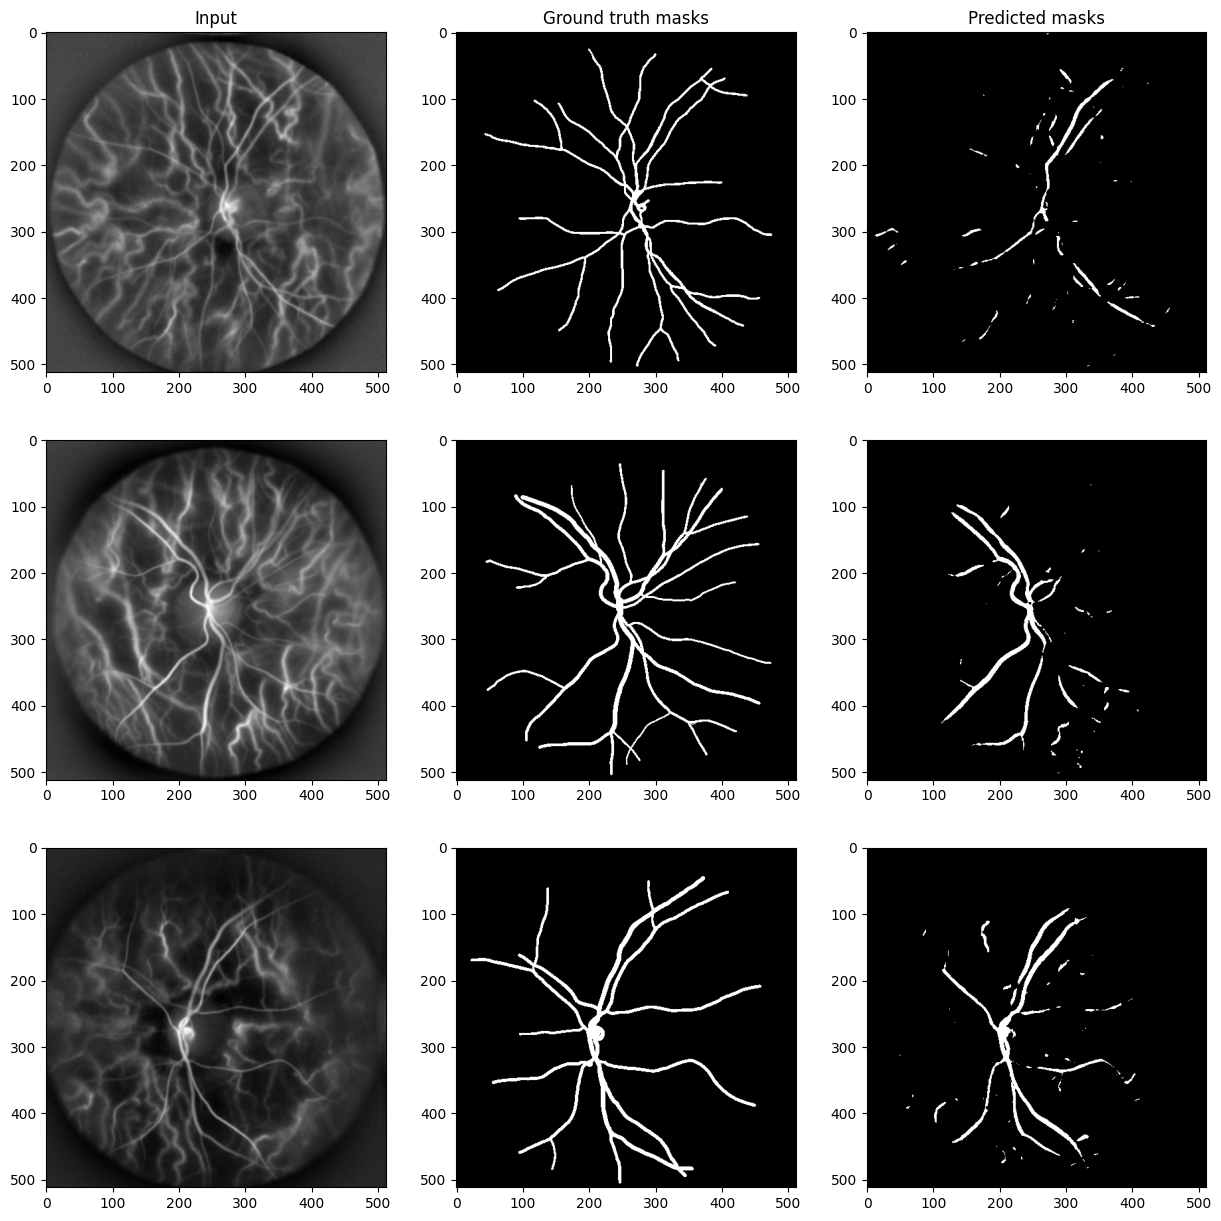

In [47]:
benchmark_binary = compare_models(
    models=root / "binary/",
    #models=root / "av_sys_corr/",
    #dataloader=dls_av_sys_corr.valid,
    dataloader=dls_binary.valid,
    metrics=[['Sensitivity', sensitivity], ['Dice', dice], ['HD95', hausdorff_distance], ['cldice', clDice]],
    # metrics=[['Dice', dice_metric], ['HD95', hausdorff_dist], ['cldice', clDice]],
    device='cuda',
    keys=['UNet'],
    show_results=True,
    n=3,
    extension=".pth"
)

In [48]:
model_name = "UNet_bilinear_ce_0.pth"
model_class = get_model_class(model_name)
model = model_utils.StateDictModel(root / "binary" / model_name, model_class, in_channels=1, n_classes=1, device='cuda')

In [49]:
benchmark_binary[['Sensitivity', 'Dice', 'cldice', 'HD95']].round(3)

,Sensitivity,Dice,cldice,HD95
model,,,,
UNet_bilinear_ce_0,0.272,0.403,0.479,53.353


In [50]:
benchmark_binary[['Sensitivity', 'Dice', 'cldice', 'HD95']].round(3)

,Sensitivity,Dice,cldice,HD95
model,,,,
UNet_bilinear_ce_0,0.272,0.403,0.479,53.353


In [51]:
benchmark_binary

,Sensitivity,Dice,HD95,cldice,inference_time,num_parameters
model,,,,,,
UNet_bilinear_ce_0,0.27218,0.402917,53.352514,0.478879,0.034117,17266241
